# Panorama Stitching

Our project belongs to the area of computer vision and image processing, specifically panoramic image stitching. 

The goal of this project is to construct an automated panorama stitching pipeline from overlapping images. Panorama stitching combines several images of the same scene into one wide image by detecting common points, matching them, estimating the geometric transformation between the images, and warping one image into the coordinate system of the other.

The complete pipeline consists of the following stages:

1. Loading the images
2. Converting images to grayscale
3. Reducing noise using Gaussian smoothing
4. Detecting keypoints (Harris corner algorithm and ORB)
5. Extracting and matching feature descriptors
6. Estimating the homography matrix
7. Removing outliers with RANSAC
8. Warping and stitching the images into a panorama

## Imports

The implementation uses the following libraries:

- `cv2` for image processing and computer vision algorithms
- `numpy` for matrix operations
- `matplotlib` for visualization
- `time` for runtime analysis

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

## Helper Functions

To make the notebook more readable, helper functions are defined for displaying color and grayscale images.

In [17]:
def show_image(img, title="Image", figsize=(8, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(img, title="Image", figsize=(8, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

## Image Loading

The input images are stored in a local folder named `images`.  
For successful panorama stitching, the images must contain overlapping regions of the same scene.

In [18]:
# Paths to input images
img1_path = "images/test1/img1.jpg"
img2_path = "images/test1/img2.jpg"

# Load images
img1 = cv2.imread(img1_path)
img2 = cv2.imread(img2_path)

# Check that images were loaded correctly
if img1 is None or img2 is None:
    print("Error: One or both images could not be loaded. Check file paths.")
else:
    print("Images loaded successfully.")
    print("Image 1 shape:", img1.shape)
    print("Image 2 shape:", img2.shape)

Images loaded successfully.
Image 1 shape: (1000, 664, 3)
Image 2 shape: (1000, 664, 3)


The loaded images are displayed to verify that the correct files were read.

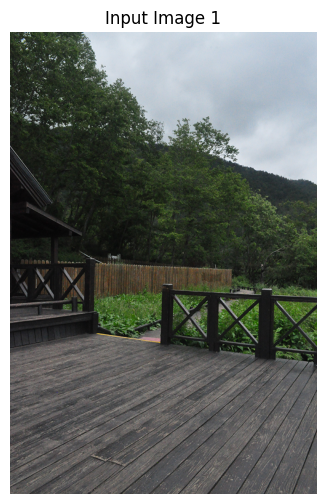

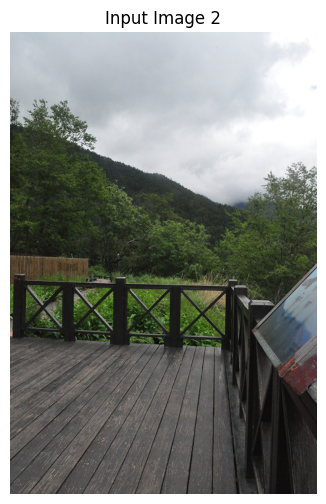

In [19]:
show_image(img1, "Input Image 1")
show_image(img2, "Input Image 2")

## Grayscale Conversion

Most feature detection methods operate on image intensity rather than color. Therefore, each image is converted from RGB/BGR to grayscale.

The color image $I_{RGB}$ exists in a 3-dimensional space:

$$
I_{RGB} \in \mathbb{R}^{H \times W \times 3}
$$

Each pixel at coordinates $(x, y)$, where $x \in \{1, 2, \dots, W\}$ and $y \in \{1, 2, \dots, H\}$, the pixel is represented by a vector of three color values:

$$
c(x,y) = \begin{bmatrix} R(x,y) \\ G(x,y) \\ B(x,y) \end{bmatrix}
$$

The grayscale pixel intensity $Y(x,y)$ for a single pixel is calculated via the dot product of the weight vector and the color vector:

$$Y(x,y) = w^\top c(x,y) = \begin{bmatrix} 0.299 & 0.587 & 0.114 \end{bmatrix} \begin{bmatrix} R(x,y) \\ G(x,y) \\ B(x,y) \end{bmatrix}$$

By applying this transformation across all coordinates $(x,y)$, the color dimension is eliminated. The resulting grayscale image $I_{gray}$ is now a 2-dimensional matrix:

$$I_{gray} \in \mathbb{R}^{H \times W}$$

The entire image is now represented by this matrix, where every element is a pixel intensity:

$$I_{gray} = \begin{bmatrix} Y(1,1) & Y(1,2) & \dots & Y(1,W) \\ Y(2,1) & Y(2,2) & \dots & Y(2,W) \\ \vdots & \vdots & \ddots & \vdots \\ Y(H,1) & Y(H,2) & \dots & Y(H,W) \end{bmatrix}$$

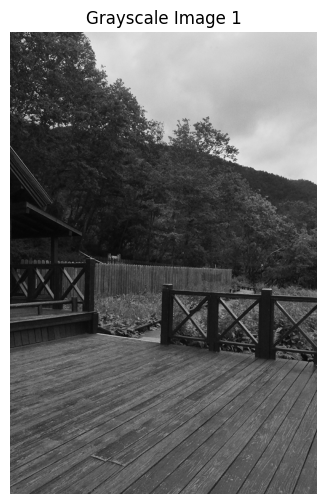

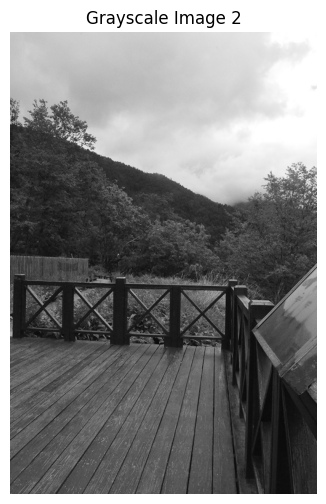

In [20]:
# Convert images to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

show_gray(gray1, "Grayscale Image 1")
show_gray(gray2, "Grayscale Image 2")

## Gaussian Smoothing

Before feature detection, images are often smoothed to reduce noise and small-scale intensity variations that could produce unstable or false features. Gaussian smoothing performs this task by convolving the image with a Gaussian kernel.

Gaussian smoothing is defined as a convolution of the image with a Gaussian kernel:

$$
I_s(x,y) = G(x,y) * I(x,y)
$$

where the Gaussian function is

$$
G(x,y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}.
$$

For digital images, the convolution is computed over a finite neighborhood around each pixel. The smoothed image intensity at location $(x,y)$ is given by:

$$I_s(x,y) = \sum_{u=-k}^{k} \sum_{v=-k}^{k} G(u,v)I(x-u,y-v)$$

where:
* $I(x,y)$ is the original grayscale image
* $I_s(x,y)$ is the smoothed image
* $G(u,v)$ is the sampled Gaussian kernel
* $(2k+1) \times (2k+1)$ is the kernel size

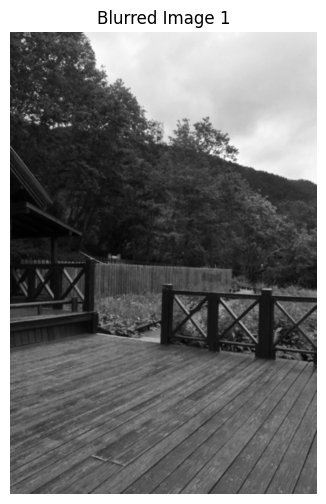

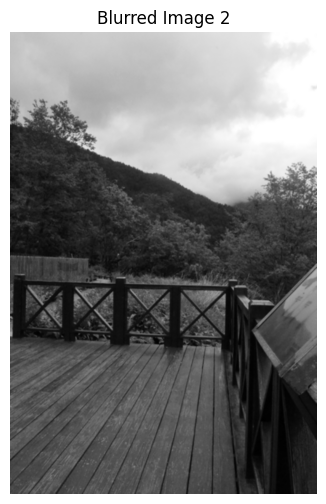

In [21]:
# Apply Gaussian blur
blur1 = cv2.GaussianBlur(gray1, (5, 5), 1.0)
blur2 = cv2.GaussianBlur(gray2, (5, 5), 1.0)

show_gray(blur1, "Blurred Image 1")
show_gray(blur2, "Blurred Image 2")

## Harris Corner Detector



## ORB